In [ ]:
# 이미지 감지 후 결과 출력
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.2 MB/s eta 0:00:00


In [21]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import datetime
import csv
import urllib.parse

In [ ]:
object_info = {
    "person": {
        "description": "이 객체는 사람이 감지된 경우입니다. 사람 감지는 보안 감시, 출입 관리 시스템 등에 매우 유용합니다. 또한 얼굴 인식, 행동 분석 등 다양한 분야에 적용됩니다.",
        "use_case": "사람 감지는 보안 시스템에서 출입 관리, 비상 상황에서의 대처, 헬스케어 분야에서 노인 및 환자의 상태 모니터링에 사용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("사람"))
    },
    "car": {
        "description": "이 객체는 자동차가 감지된 경우입니다. 자동차 감지는 교통 흐름 분석, 불법 주차 감시, 사고 예방 등 다양한 분야에 활용됩니다.",
        "use_case": "자동차 감지는 자율 주행 시스템, 스마트 교통 시스템, 교차로 모니터링 등에 활용되며, 도시 계획 및 교통 관리에도 중요한 역할을 합니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("자동차"))
    },
    "truck": {
        "description": "이 객체는 트럭이 감지된 경우입니다. 트럭 감지는 물류 창고 관리, 도로 교통 모니터링, 고속도로에서의 추적 등에 활용됩니다.",
        "use_case": "트럭 감지는 물류 효율화, 고속도로 사고 예방, 교통량 분석 등에 사용되며, 스마트 물류 및 재난 관리 시스템에도 중요합니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("트럭"))
    },
    "motorcycle": {
        "description": "이 객체는 오토바이가 감지된 경우입니다. 오토바이 감지는 교통 사고 예방 시스템, 도로에서의 차량 추적 등에 사용됩니다.",
        "use_case": "오토바이 감지는 도로 교통 사고 예방, 긴급 상황 대응, 스마트 교통 시스템 등에 사용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("오토바이"))
    },
    "dog": {
        "description": "이 객체는 강아지가 감지된 경우입니다. 강아지 감지는 반려동물 보호, 유기 동물 탐지 및 동물원 관리 등에서 중요합니다.",
        "use_case": "강아지 감지는 동물 보호 시스템, 유기 동물 탐지 시스템 및 스마트 펫 모니터링 시스템에 사용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("강아지"))
    },
    "cat": {
        "description": "이 객체는 고양이가 감지된 경우입니다. 고양이 감지는 스마트 펫 모니터링 시스템과 연계되어 유용하게 사용됩니다.",
        "use_case": "고양이 감지는 반려동물 모니터링 시스템, 동물원 관리 및 스마트 홈 시스템에 활용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("고양이"))
    },
    "bus": {
        "description": "이 객체는 버스가 감지된 경우입니다. 버스 감지는 대중교통 분석, 버스 전용차로 감시 및 혼잡도 모니터링 등에 활용됩니다.",
        "use_case": "버스 감지는 스마트 시티 교통 시스템, 버스 정류장 혼잡도 분석 및 통근 시간 최적화에 사용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("버스"))
    },
    "bird": {
        "description": "이 객체는 새가 감지된 경우입니다. 새 감지는 자연 생태 모니터링, 조류 충돌 방지 시스템 등에 활용됩니다.",
        "use_case": "새 감지는 공항의 조류 충돌 방지 시스템, 야생 동물 보호 구역의 생태계 분석, 스마트 환경 감시 시스템에 활용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("새"))
    }
}


0: 480x640 1 person, 1 truck, 2 dogs, 184.1ms
Speed: 10.8ms preprocess, 184.1ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)
output_20260519_015623.jpg 파일로 감지된 이미지 저장


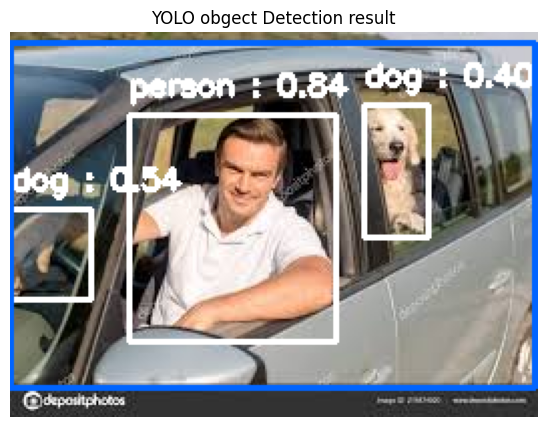

In [ ]:
model = YOLO('yolo11n.pt')

# 감지할 이미지
image_path = "test.jpeg"
image = cv2.imread(image_path)

if image is None:
  print('이미지가 없어요')
  exit()

results = model(image)

detected_objects = []

for result in results:
  for box in result.boxes:
    x1,y1,x2,y2 = map(int, box.xyxy[0])
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    detected_objects.append(label)

    # 객체별 색상 지정
    colors = {
        'preson':(255, 0, 0),
        'car':(0, 255, 0),
        'truck':(255, 100, 0),
        'motorcycle':(255, 255, 0),
        'dogf':(155, 0, 200),
        'cat':(255, 50, 210),
        'bus':(0, 0, 255),
        'bird':(5, 10, 20)
    }
    color = colors.get(label, (255 ,255, 255))
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

    # 객체명 + 신뢰도 표시
    cv2.putText(
        image,
        f'{label} : {confidence:.2f}',
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        2
    )

# 결과 이미지 파일로 저장 (시간대별)
timestmap = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
output_path = f'output_{timestmap}.jpg'
cv2.imwrite(output_path, image)
print(f'{output_path} 파일로 감지된 이미지 저장')

plt.figure(figsize=(12, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('YOLO obgect Detection result')
plt.show()

In [ ]:
from cv2.gapi.streaming import timestamp
# 감지된 객체에 대한 설명 및 링크
description_text = ""

for obj in set(detected_objects):
  if obj in object_info:
    description_text += f'\n[{obj} 감지됨]\n'
    description_text += f'설명:{object_info[obj]['description']}\n'
    description_text += f'사용 사례:{object_info[obj]['use_case']}\n'
    description_text += f'내용:{object_info[obj]['link']}\n'

print('객체 설명 : ', description_text)

log_file = 'yolo4desc.txt'

with open(log_file, mode='w', encoding='utf-8') as log:
  log.write(f'[{timestamp}] 감지된 객체 : {', '.join(set(detected_objects))}\n')
  log.write(description_text + '\n\n')

print(f'객체 감지 정보가 {log_file}에 저장')

객체 설명 :  
[dog 감지됨]
설명:이 객체는 강아지가 감지된 경우입니다. 강아지 감지는 반려동물 보호, 유기 동물 탐지 및 동물원 관리 등에서 중요합니다.
사용 사례:강아지 감지는 동물 보호 시스템, 유기 동물 탐지 시스템 및 스마트 펫 모니터링 시스템에 사용됩니다.
내용:https://ko.wikipedia.org/wiki/%EA%B0%95%EC%95%84%EC%A7%80

[truck 감지됨]
설명:이 객체는 트럭이 감지된 경우입니다. 트럭 감지는 물류 창고 관리, 도로 교통 모니터링, 고속도로에서의 추적 등에 활용됩니다.
사용 사례:트럭 감지는 물류 효율화, 고속도로 사고 예방, 교통량 분석 등에 사용되며, 스마트 물류 및 재난 관리 시스템에도 중요합니다.
내용:https://ko.wikipedia.org/wiki/%ED%8A%B8%EB%9F%AD

[person 감지됨]
설명:이 객체는 사람이 감지된 경우입니다. 사람 감지는 보안 감시, 출입 관리 시스템 등에 매우 유용합니다. 또한 얼굴 인식, 행동 분석 등 다양한 분야에 적용됩니다.
사용 사례:사람 감지는 보안 시스템에서 출입 관리, 비상 상황에서의 대처, 헬스케어 분야에서 노인 및 환자의 상태 모니터링에 사용됩니다.
내용:https://ko.wikipedia.org/wiki/%EC%82%AC%EB%9E%8C

객체 감지 정보가 yolo4desc.txt에 저장


객체 갯수 : 
person : 1개
dog : 2개
truck : 1개
객체 통계가 yolo4obj_stat.csv로 저장~~~


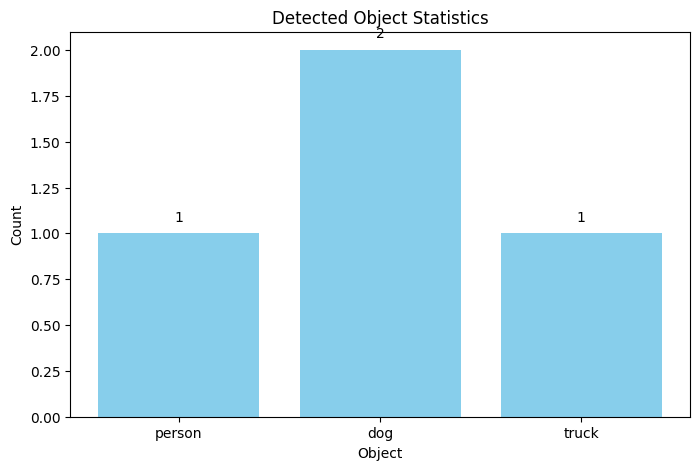

In [ ]:
# 객체 갯수 세기
from collections import Counter
obj_count = Counter(detected_objects)
print('객체 갯수 : ')
for obj, count in obj_count.items():
  print(f'{obj} : {count}개')

# 객체 등장 시간 CSV로 저장
csv_file = 'yolo4obj_stat.csv'
with open(csv_file, mode='w', newline='', encoding='utf-8') as f:
  writer = csv.writer(f)

  for obj in detected_objects:
    writer.writerow([timestamp, obj])
print(f'객체 통계가 {csv_file}로 저장~~~')

# 특정 객체 위험 감지
danger_obj = ['knife', 'fire','motorcycle']
for obj in detected_objects:
  if obj in danger_obj:
    print(f'위험 객체 감지 됨 : {obj}')

# 객체 갯수 막대 그래프로 출력
labels = list(obj_count.keys())
counts = list(obj_count.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color='skyblue')

plt.title('Detected Object Statistics')
plt.xlabel('Object')
plt.ylabel('Count')

for b in bars:
    height = b.get_height()
    plt.text(
        b.get_x() + b.get_width() / 2,
        height + 0.05,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.show()

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%')
plt.show()